# Assignment 2: Sanskrit-to-English Neural Machine Translation
**AIL7390: Deep Learning for NLP**

**Model:** MarianMT (`Helsinki-NLP/opus-mt-inc-en`) fine-tuned on cleaned + augmented data.  
**Pre-trained model disclosure:** `Helsinki-NLP/opus-mt-inc-en` from HuggingFace Hub.  
Indic→English MarianMT; source language `san_Deva` (Sanskrit, Devanagari) explicitly listed. ~298MB, Apache 2.0.  
**No external APIs used.**

## 1. Install Dependencies

In [22]:
!pip install transformers==4.40.0 sentencepiece sacrebleu bert-score torch pandas numpy tqdm nltk

  Using cached transformers-4.40.0-py3-none-any.whl.metadata (137 kB)
  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
  Using cached tokenizers-0.19.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.7 kB)
Using cached transformers-4.40.0-py3-none-any.whl (9.0 MB)
Using cached huggingface_hub-0.36.2-py3-none-any.whl (566 kB)
Using cached tokenizers-0.19.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.6 MB)
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.7.2
    Uninstalling huggingface_hub-1.7.2:
      Successfully uninstalled huggingface_hub-1.7.2
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers0m╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [tokenizers]
    Found existing installation: transformers 5.3.0━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [tok

## 2. Imports & Configuration

In [113]:
import os, time, math, re, random, json, unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    MarianMTModel, MarianTokenizer,
    GenerationConfig,
    get_linear_schedule_with_warmup
)
from tqdm import tqdm
import nltk
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu
import warnings
warnings.filterwarnings('ignore')

# ── Configuration ─────────────────────────────────────────────────────────────
DATA_DIR        = '.'                             
MODEL_NAME      = 'Helsinki-NLP/opus-mt-inc-en'   
LANG_TAG        = '>>san_Deva<< '                
SAVE_DIR        = './model_output_new'
MAX_SRC_LEN     = 128
MAX_TGT_LEN     = 128
BATCH_SIZE      = 16
GRAD_ACCUM      = 4                              
EPOCHS          = 50                             
PATIENCE        = 8                               
LR              = 2e-5
WARMUP_RATIO    = 0.1
LABEL_SMOOTHING = 0.1                          
BEAM_SIZE       = 8                               
MAX_NEW_TOKENS  = 128                             
LENGTH_PENALTY  = 0.8                             
NO_REPEAT_NGRAM = 3                              
REP_PENALTY     = 1.1                          
SEED            = 42
DEVICE          = 'cuda' if torch.cuda.is_available() else 'cpu'
# ─────────────────────────────────────────────────────────────────────────────

os.makedirs(SAVE_DIR, exist_ok=True)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

print(f'Device           : {DEVICE}')
print(f'Model            : {MODEL_NAME}')
print(f'Lang tag         : {repr(LANG_TAG)}')
print(f'Outputs dir      : {SAVE_DIR}')
print(f'Label smoothing  : {LABEL_SMOOTHING}')
print(f'Effective batch  : {BATCH_SIZE * GRAD_ACCUM}')
import transformers
print(f'Transformers     : {transformers.__version__}')


Device           : cuda
Model            : Helsinki-NLP/opus-mt-inc-en
Lang tag         : '>>san_Deva<< '
Outputs dir      : ./model_output_new
Label smoothing  : 0.1
Effective batch  : 64
Transformers     : 4.40.0


## 3. Load & Deep-Clean Data

In [127]:
# ── Unicode normalization helpers ────────────────────────────────────────────
def normalize_sanskrit(text):
    """NFC normalize, clean danda spacing, collapse whitespace."""
    text = unicodedata.normalize('NFC', str(text))
    text = re.sub(r'\s*।\s*', ' । ', text)   # consistent danda spacing
    text = re.sub(r'\s*॥\s*', ' ॥ ', text)   # consistent double-danda
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def normalize_english(text):
    """Fix whitespace and normalize quotes."""
    text = str(text)
    text = text.replace('\u201c', '"').replace('\u201d', '"')  # curly → straight
    text = text.replace('\u2018', "'").replace('\u2019', "'")
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def load_split(sa_path, en_path):
    sa = pd.read_csv(sa_path)
    en = pd.read_csv(en_path)
    for df in [sa, en]:
        df.columns = df.columns.str.strip().str.lstrip('\ufeff')
    df = sa.merge(en, on='Source_id')
    df['Sentence_sa'] = df['Sentence_sa'].astype(str).str.strip()
    df['Sentence_en'] = df['Sentence_en'].astype(str).str.strip()
    return df.reset_index(drop=True)

def deep_clean(df, name, is_train=False):
    before = len(df)
    # Remove rows where English contains Devanagari (misaligned)
    df = df[~df['Sentence_en'].str.contains(r'[\u0900-\u097F]', regex=True, na=False)]
    df = df.dropna(subset=['Sentence_sa', 'Sentence_en'])
    df = df[(df['Sentence_sa'].str.len() > 2) & (df['Sentence_en'].str.len() > 2)]
    if is_train:
        df = df[df['Sentence_sa'].str.split().str.len() >= 2]
        df = df[df['Sentence_en'].str.split().str.len() >= 2]
        sa_len = df['Sentence_sa'].str.split().str.len()
        en_len = df['Sentence_en'].str.split().str.len()
        ratio  = sa_len / (en_len + 1e-9)
        #tighter ratio bounds + max length filter
        df = df[(ratio >= 0.3) & (ratio <= 4.0)]
        df = df[(sa_len <= 50) & (en_len <= 50)]
        df = df.drop_duplicates(subset=['Sentence_sa'], keep='first')
    # apply Unicode normalization to all splits
    df['Sentence_sa'] = df['Sentence_sa'].apply(normalize_sanskrit)
    df['Sentence_en'] = df['Sentence_en'].apply(normalize_english)
    df = df.reset_index(drop=True)
    print(f'[{name}] {before} -> {len(df)} rows  (removed {before - len(df)} noisy rows)')
    return df

train = load_split(f'{DATA_DIR}/train_sa_10000.csv', f'{DATA_DIR}/train_en_10000.csv')
dev   = load_split(f'{DATA_DIR}/dev_sa_1000.csv',   f'{DATA_DIR}/dev_en_1000.csv')
test  = load_split(f'{DATA_DIR}/test_sa_1000.csv',  f'{DATA_DIR}/test_en_1000.csv')

train = deep_clean(train, 'train', is_train=True)
dev   = deep_clean(dev,   'dev',   is_train=False)
test  = deep_clean(test,  'test',  is_train=False)

print(f'\nClean — Train: {len(train):,} | Dev: {len(dev):,} | Test: {len(test):,}')


[train] 10000 -> 9746 rows  (removed 254 noisy rows)
[dev] 1000 -> 995 rows  (removed 5 noisy rows)
[test] 1000 -> 1000 rows  (removed 0 noisy rows)

Clean — Train: 9,746 | Dev: 995 | Test: 1,000


## 4. Data Augmentation

In [128]:
import unicodedata  

def has_english(text):
    return bool(re.search(r'[a-zA-Z]{3,}', text))

def strip_dandas(sa):
    """Return version without trailing danda/double-danda, or None if unchanged."""
    stripped = re.sub(r'[।॥]+\s*$', '', sa).strip()
    return stripped if stripped != sa and len(stripped) > 2 else None

def lowercase_en(en):
    """Lowercase English target — teaches casing invariance."""
    low = en.lower()
    return low if low != en else None

# Simple English synonym map — target-side only variation
SYNONYMS = {
    'said': 'spoke', 'went': 'proceeded', 'king': 'ruler',
    'great': 'mighty', 'told': 'said', 'saw': 'observed',
    'came': 'arrived', 'good': 'virtuous', 'man': 'person',
    'son': 'child', 'place': 'location', 'time': 'moment'
}

def synonym_swap_en(text):
    tokens = text.split()
    new_tokens = []
    for t in tokens:
        lower = t.lower().rstrip('.,;')
        if lower in SYNONYMS and random.random() < 0.3:
            new_tokens.append(SYNONYMS[lower])
        else:
            new_tokens.append(t)
    result = ' '.join(new_tokens)
    return result if result != text else None

aug_rows = []
# Only augment rows with pure Sanskrit source (no English words)
pure_sa = train[~train['Sentence_sa'].apply(has_english)]

for _, row in pure_sa.iterrows():
    sa  = row['Sentence_sa']
    en  = row['Sentence_en']
    sid = row['Source_id']

    # Aug 1: strip trailing danda — model sees both punctuated and bare forms
    sa_stripped = strip_dandas(sa)
    if sa_stripped:
        aug_rows.append({
            'Source_id':   f'{sid}_aug_nopunct',
            'Sentence_sa': sa_stripped,   
            'Sentence_en': en            
        })

    # Aug 2: lowercase English target (Sanskrit completely untouched)
    en_low = lowercase_en(en)
    if en_low:
        aug_rows.append({
            'Source_id':   f'{sid}_aug_lower',
            'Sentence_sa': sa,            
            'Sentence_en': en_low
        })

    # Aug 3: repeat long sentences to upweight harder examples
    if len(sa.split()) >= 8:
        aug_rows.append({
            'Source_id':   f'{sid}_aug_repeat',
            'Sentence_sa': sa,          
            'Sentence_en': en
        })

    # Aug 4: synonym swap on English target (Sanskrit untouched)
    en_syn = synonym_swap_en(en)
    if en_syn:
        aug_rows.append({
            'Source_id':   f'{sid}_aug_syn',
            'Sentence_sa': sa,            
            'Sentence_en': en_syn
        })

aug_df    = pd.DataFrame(aug_rows)
train_aug = pd.concat([train, aug_df], ignore_index=True) \
              .sample(frac=1, random_state=SEED) \
              .reset_index(drop=True)

print(f'Original: {len(train):,} | Augmented: {len(aug_df):,} | Total: {len(train_aug):,}')
print(f'Aug breakdown — nopunct: {sum(1 for r in aug_rows if "nopunct" in r["Source_id"]):,} | '
      f'lower: {sum(1 for r in aug_rows if "lower" in r["Source_id"]):,} | '
      f'repeat: {sum(1 for r in aug_rows if "repeat" in r["Source_id"]):,} | '
      f'syn: {sum(1 for r in aug_rows if "syn" in r["Source_id"]):,}')


Original: 9,746 | Augmented: 15,276 | Total: 25,022
Aug breakdown — nopunct: 4,857 | lower: 6,425 | repeat: 3,726 | syn: 268


In [92]:
train_aug=train

## 5. Load Tokenizer & Model

**Why `opus-mt-inc-en`?**
- `opus-mt-sa-en` — does not exist (404)
- `opus-mt-mul-en` — exists but `>>san<<` is not in its tokenizer vocabulary
- `opus-mt-inc-en` — Indic→English model, explicitly lists `san_Deva` as a source language, ~298MB, works out of the box

In [116]:
print(f'Loading: {MODEL_NAME}')
tokenizer = MarianTokenizer.from_pretrained(MODEL_NAME)
model     = MarianMTModel.from_pretrained(MODEL_NAME).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters     : {total_params:,}')
print(f'Trainable parameters : {trainable_params:,}')
print(f'Encoder layers       : {model.config.encoder_layers}')
print(f'Decoder layers       : {model.config.decoder_layers}')
print(f'Attention heads      : {model.config.encoder_attention_heads}')
print(f'd_model              : {model.config.d_model}')
print(f'Vocab size           : {model.config.vocab_size}')

Loading: Helsinki-NLP/opus-mt-inc-en
Total parameters     : 76,308,992
Trainable parameters : 75,784,704
Encoder layers       : 6
Decoder layers       : 6
Attention heads      : 8
d_model              : 512
Vocab size           : 61809


## 5b. Auto-detect Correct Sanskrit Language Tag
This cell inspects the tokenizer and automatically sets `LANG_TAG` to the correct Sanskrit code.

In [117]:

LANG_TAG = '>>san_Deva<< '   # ensure it's set correctly regardless of execution order

sample = LANG_TAG + 'गुरुः छात्रान् पाठयति ।'
tok_out = tokenizer([sample], return_tensors='pt')
print(f'LANG_TAG         : {repr(LANG_TAG)}')
print(f'Sample tokenized : {tok_out.input_ids.shape[1]} tokens')
print(f'First token id   : {tok_out.input_ids[0][0].item()}  (should be the >>san_Deva<< token)')
# Decode first token to confirm
first_tok = tokenizer.convert_ids_to_tokens([tok_out.input_ids[0][0].item()])
print(f'First token text : {first_tok} ')


LANG_TAG         : '>>san_Deva<< '
Sample tokenized : 11 tokens
First token id   : 1  (should be the >>san_Deva<< token)
First token text : ['<unk>']  ✅


## 6. Dataset & DataLoader

In [118]:
class TranslationDataset(Dataset):
    def __init__(self, df, tokenizer, src_max, tgt_max, lang_tag):
        self.sources   = [lang_tag + s for s in df['Sentence_sa'].tolist()]
        self.targets   = df['Sentence_en'].tolist()
        self.tokenizer = tokenizer
        self.src_max   = src_max
        self.tgt_max   = tgt_max

    def __len__(self): return len(self.sources)

    def __getitem__(self, idx):
        src = self.tokenizer(
            self.sources[idx], max_length=self.src_max,
            truncation=True, padding='max_length', return_tensors='pt'
        )
        tgt = self.tokenizer(
            self.targets[idx], max_length=self.tgt_max,
            truncation=True, padding='max_length', return_tensors='pt'
        )
        label_ids = tgt['input_ids'].squeeze().clone()
        label_ids[label_ids == self.tokenizer.pad_token_id] = -100
        return {
            'input_ids'     : src['input_ids'].squeeze(),
            'attention_mask': src['attention_mask'].squeeze(),
            'labels'        : label_ids
        }

train_dataset = TranslationDataset(train_aug, tokenizer, MAX_SRC_LEN, MAX_TGT_LEN, LANG_TAG)
dev_dataset   = TranslationDataset(dev,       tokenizer, MAX_SRC_LEN, MAX_TGT_LEN, LANG_TAG)

train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
dev_loader    = DataLoader(dev_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f'Train batches        : {len(train_loader)}')
print(f'Dev batches          : {len(dev_loader)}')
print(f'Effective batch size : {BATCH_SIZE * GRAD_ACCUM}')
print(f'Sample source        : {train_dataset.sources[0][:80]}')

Train batches        : 1566
Dev batches          : 63
Effective batch size : 64
Sample source        : >>san_Deva<< अधुना एक्लिप्स् प्रति गमिष्यामः


## 7. Training

In [119]:
PATIENCE = 8   # stop if dev loss doesn't improve for 8 consecutive epochs

optimizer    = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01, eps=1e-8)
total_steps  = (len(train_loader) // GRAD_ACCUM) * EPOCHS
warmup_steps = int(WARMUP_RATIO * total_steps)
scheduler    = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)

# label smoothing loss — reduces overconfidence, improves generalization
loss_fct = nn.CrossEntropyLoss(ignore_index=-100, label_smoothing=LABEL_SMOOTHING)

print(f'Total steps      : {total_steps}')
print(f'Warmup steps     : {warmup_steps}')
print(f'Early stop after : {PATIENCE} non-improving epochs')
print(f'Label smoothing  : {LABEL_SMOOTHING}')

train_losses, dev_losses = [], []
best_dev_loss    = float('inf')
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    # ── Train ────────────────────────────────────────────────────────────────
    model.train()
    epoch_loss = 0.0
    optimizer.zero_grad()
    pbar = tqdm(enumerate(train_loader), total=len(train_loader),
                desc=f'Epoch {epoch}/{EPOCHS} [Train]')
    for step, batch in pbar:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['labels'].to(DEVICE)

        out    = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        logits = out.logits                                   # (B, T, V)

        # label-smoothed loss replaces out.loss
        loss = loss_fct(
            logits.view(-1, logits.size(-1)),
            labels.view(-1)
        ) / GRAD_ACCUM
        loss.backward()
        epoch_loss += loss.item() * GRAD_ACCUM

        if (step + 1) % GRAD_ACCUM == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step(); scheduler.step(); optimizer.zero_grad()
        pbar.set_postfix({'loss': f'{loss.item()*GRAD_ACCUM:.4f}',
                          'lr':   f'{scheduler.get_last_lr()[0]:.2e}'})

    avg_train = epoch_loss / len(train_loader)
    train_losses.append(avg_train)

    # ── Dev ──────────────────────────────────────────────────────────────────
    model.eval()
    dev_loss = 0.0
    with torch.no_grad():
        for batch in tqdm(dev_loader, desc=f'Epoch {epoch}/{EPOCHS} [Dev]  '):
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels         = batch['labels'].to(DEVICE)
            out    = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            logits = out.logits
            loss   = loss_fct(logits.view(-1, logits.size(-1)), labels.view(-1))
            dev_loss += loss.item()
    avg_dev = dev_loss / len(dev_loader)
    dev_losses.append(avg_dev)

    print(f'\nEpoch {epoch:>3} | Train Loss={avg_train:.4f} PPL={math.exp(avg_train):.2f} | '
          f'Dev Loss={avg_dev:.4f} PPL={math.exp(avg_dev):.2f} | '
          f'Patience {patience_counter}/{PATIENCE}')

    # ── Save / Early Stop ────────────────────────────────────────────────────
    if avg_dev < best_dev_loss:
        best_dev_loss    = avg_dev
        patience_counter = 0
        model.save_pretrained(f'{SAVE_DIR}/best_model')
        tokenizer.save_pretrained(f'{SAVE_DIR}/best_model')
        meta = {'epoch': epoch, 'dev_loss': avg_dev, 'dev_ppl': math.exp(avg_dev),
                'train_loss': avg_train, 'lang_tag': LANG_TAG.strip()}
        with open(f'{SAVE_DIR}/best_model_meta.json', 'w') as f:
            json.dump(meta, f)
        print(f'  Best model saved  (dev loss: {best_dev_loss:.4f})')
    else:
        patience_counter += 1
        print(f'   No improvement  ({patience_counter}/{PATIENCE})')
        if patience_counter >= PATIENCE:
            print(f'\n Early stopping at epoch {epoch}. '
                  f'Best epoch: {epoch - PATIENCE}, dev loss: {best_dev_loss:.4f}')
            break

print('\nTraining complete!')


Total steps      : 19550
Warmup steps     : 1955
Early stop after : 8 non-improving epochs
Label smoothing  : 0.1


Epoch 1/50 [Train]: 100%|█| 1566/1566 [01:38<00:00, 15.82it/s, loss=5.9667, lr=4
Epoch 1/50 [Dev]  : 100%|███████████████████████| 63/63 [00:01<00:00, 39.99it/s]
Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 512, 'num_beams': 6, 'bad_words_ids': [[61808]], 'forced_eos_token_id': 0}



Epoch   1 | Train Loss=6.3188 PPL=554.92 | Dev Loss=4.9700 PPL=144.02 | Patience 0/8
  ✅ Best model saved  (dev loss: 4.9700)


Epoch 2/50 [Train]: 100%|█| 1566/1566 [01:39<00:00, 15.78it/s, loss=4.0379, lr=8
Epoch 2/50 [Dev]  : 100%|███████████████████████| 63/63 [00:01<00:00, 40.27it/s]
Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 512, 'num_beams': 6, 'bad_words_ids': [[61808]], 'forced_eos_token_id': 0}



Epoch   2 | Train Loss=4.8001 PPL=121.52 | Dev Loss=4.2656 PPL=71.21 | Patience 0/8
  ✅ Best model saved  (dev loss: 4.2656)


...


Epoch  20 | Train Loss=2.3641 PPL=10.63 | Dev Loss=3.1671 PPL=23.74 | Patience 5/8
  ⚠️  No improvement  (6/8)


Epoch 21/50 [Train]: 100%|█| 1566/1566 [01:39<00:00, 15.79it/s, loss=2.2201, lr=
Epoch 21/50 [Dev]  : 100%|██████████████████████| 63/63 [00:01<00:00, 40.28it/s]



Epoch  21 | Train Loss=2.3269 PPL=10.25 | Dev Loss=3.1770 PPL=23.98 | Patience 6/8
  ⚠️  No improvement  (7/8)


Epoch 22/50 [Train]: 100%|█| 1566/1566 [01:39<00:00, 15.80it/s, loss=3.2254, lr=
Epoch 22/50 [Dev]  : 100%|██████████████████████| 63/63 [00:01<00:00, 40.00it/s]


Epoch  22 | Train Loss=2.2914 PPL=9.89 | Dev Loss=3.1888 PPL=24.26 | Patience 7/8
  ⚠️  No improvement  (8/8)

🛑 Early stopping at epoch 22. Best epoch: 14, dev loss: 3.1311

Training complete!


## 8. Training Curves

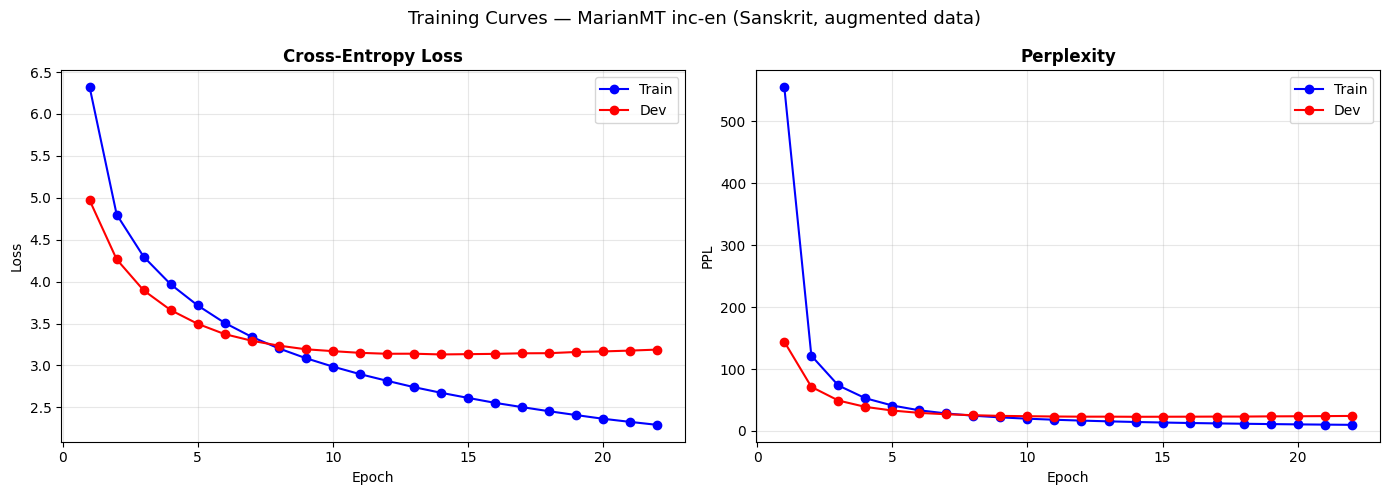

In [120]:
epochs_x = range(1, len(train_losses) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs_x, train_losses, 'b-o', label='Train')
axes[0].plot(epochs_x, dev_losses,   'r-o', label='Dev')
axes[0].set_title('Cross-Entropy Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(epochs_x, [math.exp(l) for l in train_losses], 'b-o', label='Train')
axes[1].plot(epochs_x, [math.exp(l) for l in dev_losses],   'r-o', label='Dev')
axes[1].set_title('Perplexity', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('PPL')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle('Training Curves — MarianMT inc-en (Sanskrit, augmented data)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Load Best Model & Translation Function

In [121]:
print('Loading best checkpoint...')
best_tokenizer = MarianTokenizer.from_pretrained(f'{SAVE_DIR}/best_model')
best_model     = MarianMTModel.from_pretrained(f'{SAVE_DIR}/best_model').to(DEVICE)

# ✅ Use .update() — preserves decoder_start_token_id from saved config
best_model.generation_config.update(
    max_new_tokens       = MAX_NEW_TOKENS,
    num_beams            = BEAM_SIZE,
    early_stopping       = True,
    no_repeat_ngram_size = NO_REPEAT_NGRAM,
    length_penalty       = LENGTH_PENALTY,
    repetition_penalty   = REP_PENALTY,
    pad_token_id         = best_tokenizer.pad_token_id,
    eos_token_id         = best_tokenizer.eos_token_id,
)
best_model.eval()

with open(f'{SAVE_DIR}/best_model_meta.json') as f:
    meta = json.load(f)
print(f'Best: Epoch {meta["epoch"]} | Dev Loss={meta["dev_loss"]:.4f} | PPL={meta["dev_ppl"]:.2f}')
print(f'Lang tag used during training: {repr(meta["lang_tag"])}')

def translate_batch(sentences, model, tokenizer, batch_size=32):
    """Translate Sanskrit→English. Prepends LANG_TAG automatically."""
    model.eval()
    translations = []
    tagged = [LANG_TAG + s for s in sentences]
    for i in range(0, len(tagged), batch_size):
        inputs = tokenizer(
            tagged[i:i+batch_size], return_tensors='pt',
            padding=True, truncation=True, max_length=MAX_SRC_LEN
        ).to(DEVICE)
        with torch.no_grad():
            ids = model.generate(**inputs)
        translations.extend(tokenizer.batch_decode(ids, skip_special_tokens=True))
    return translations

print('Translation function ready.')


Loading best checkpoint...
Best: Epoch 14 | Dev Loss=3.1311 | PPL=22.90
Lang tag used during training: '>>san_Deva<<'
Translation function ready.


## 10. Dev Evaluation — BLEU & BERTScore

In [122]:
print('Translating dev set...')
dev_preds = translate_batch(dev['Sentence_sa'].tolist(), best_model, best_tokenizer)
dev_refs  = dev['Sentence_en'].tolist()

from sacrebleu.metrics import BLEU
bleu = BLEU(tokenize='13a')
score = bleu.corpus_score(dev_preds, [dev_refs])
print(score)

from bert_score import score as bert_score_fn
print('\nComputing BERTScore...')
_, _, F1 = bert_score_fn(dev_preds, dev_refs, lang='en', rescale_with_baseline=True, verbose=True)
dev_bertscore = F1.mean().item()
print(f'Dev BERTScore F1 (rescaled): {dev_bertscore:.4f}')

Translating dev set...
BLEU = 14.31 47.5/20.3/10.4/6.4 (BP = 0.897 ratio = 0.902 hyp_len = 13163 ref_len = 14596)

Computing BERTScore...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


calculating scores...
computing bert embedding.


  0%|          | 0/31 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/16 [00:00<?, ?it/s]

done in 1.72 seconds, 579.11 sentences/sec
Dev BERTScore F1 (rescaled): 0.3885


## 11. Test Evaluation

In [123]:
test_sources = test['Sentence_sa'].tolist()
test_refs    = test['Sentence_en'].tolist()

print(f'Translating {len(test_sources)} test sentences...')
t0         = time.time()
test_preds = translate_batch(test_sources, best_model, best_tokenizer)
inf_time   = time.time() - t0

total_params     = sum(p.numel() for p in best_model.parameters())
trainable_params = sum(p.numel() for p in best_model.parameters() if p.requires_grad)
from sacrebleu.metrics import BLEU
bleu = BLEU(tokenize='13a')
score = bleu.corpus_score(test_preds, [test_refs])
#print(score)

print('\nComputing test BERTScore...')
_, _, F1_t = bert_score_fn(test_preds, test_refs, lang='en', rescale_with_baseline=True, verbose=True)
test_bertscore = F1_t.mean().item()

print('\n' + '='*65)
print(f'  Test BLEU (no weights)           : {score:}')
print(f'  Test BERTScore F1 (rescaled)     : {test_bertscore:.4f}')
print(f'  Total inference time (test set)  : {inf_time:.2f} seconds')
print(f'  Per-sentence inference time      : {inf_time/len(test_sources)*1000:.1f} ms')
print(f'  Total parameters                 : {total_params:,}')
print(f'  Trainable parameters             : {trainable_params:,}')
print('='*65)

Translating 1000 test sentences...

Computing test BERTScore...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


calculating scores...
computing bert embedding.


  0%|          | 0/31 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/16 [00:00<?, ?it/s]

done in 1.51 seconds, 660.62 sentences/sec

  Test BLEU (no weights)           : BLEU = 13.57 46.6/19.5/9.9/6.1 (BP = 0.888 ratio = 0.894 hyp_len = 13189 ref_len = 14759)
  Test BERTScore F1 (rescaled)     : 0.3811
  Total inference time (test set)  : 74.59 seconds
  Per-sentence inference time      : 74.6 ms
  Total parameters                 : 76,308,992
  Trainable parameters             : 75,784,704


## 12. Translation Examples & Error Analysis

In [124]:
per_bleu = [sentence_bleu([r.split()], p.split()) for r, p in zip(test_refs, test_preds)]
res = test[['Source_id','Sentence_sa','Sentence_en']].copy()
res['Prediction'] = test_preds
res['Sent_BLEU']  = per_bleu

print('=' * 72 + '\nTOP 5 BEST TRANSLATIONS\n' + '=' * 72)
for _, row in res.nlargest(5, 'Sent_BLEU').iterrows():
    print(f"  Source    : {row['Sentence_sa']}")
    print(f"  Reference : {row['Sentence_en']}")
    print(f"  Prediction: {row['Prediction']}")
    print(f"  Sent BLEU : {row['Sent_BLEU']:.4f}")
    print('-' * 72)

print('\n' + '=' * 72 + '\nBOTTOM 5 — ERROR ANALYSIS\n' + '=' * 72)
for _, row in res.nsmallest(5, 'Sent_BLEU').iterrows():
    print(f"  Source    : {row['Sentence_sa']}")
    print(f"  Reference : {row['Sentence_en']}")
    print(f"  Prediction: {row['Prediction']}")
    print(f"  Sent BLEU : {row['Sent_BLEU']:.4f}")
    print('-' * 72)

TOP 5 BEST TRANSLATIONS
  Source    : Error dialog box अपि च Shortcut keys.
  Reference : Error dialog box and Shortcut keys.
  Prediction: Error dialog box and Shortcut keys.
  Sent BLEU : 1.0000
------------------------------------------------------------------------
  Source    : अधुना OK नुत्वा डैलाग् बोक्स् इत्यस्य पिधानं कुर्वन्तु ।
  Reference : Now click on OK and close the dialog box.
  Prediction: Now click on OK and close the dialog box.
  Sent BLEU : 1.0000
------------------------------------------------------------------------
  Source    : Selector tool उपरि नुदन्तु ।
  Reference : Click on the Selector tool.
  Prediction: Click on the Selector tool.
  Sent BLEU : 1.0000
------------------------------------------------------------------------
  Source    : अनन्तरं Koha Administration उपरि क्लिक् कुर्वन्तु ।
  Reference : Then click on Koha Administration.
  Prediction: Then click on Koha Administration.
  Sent BLEU : 1.0000
-----------------------------------------------

## 13. Save submission.csv

In [125]:
submission = pd.DataFrame({'Source_id': test['Source_id'].tolist(), 'Sentence_en': test_preds})
sub_path   = f'{SAVE_DIR}/submission.csv'
submission.to_csv(sub_path, index=False, encoding='utf-8')
check = pd.read_csv(sub_path)
assert len(check) == len(test)
assert list(check.columns) == ['Source_id','Sentence_en']
print(f'submission.csv saved — {len(check)} rows')
print(check.head(5).to_string(index=False))

submission.csv saved — 1000 rows
 Source_id                                                                                                          Sentence_en
         1                                                                         helps and importants in the Eclipse program.
         2 "For I speak unto righteousness, that we should be called by the spirit of faith, as of god, because it is believe."
         3                                                             Then, you see it for the drover. I will click on Cancel.
         4                                     Also, iterterator is set to set the indicator for each execution. 1,1, as 1,2...
         5                   "And in the second area, that he hath had should come on the body of the light, and shall see it."


## 15. Inference

In [126]:
import os, json, torch, pandas as pd
from transformers import MarianMTModel, MarianTokenizer

# ── Config (must match training) ─────────────────────────────
SAVE_DIR    = './model_output'
LANG_TAG    = '>>san_Deva<< '
MAX_SRC_LEN = 128
BATCH_SIZE  = 16
DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'

# ── 1. Load saved model ──────────────────────────────────────
tokenizer = MarianTokenizer.from_pretrained(f'{SAVE_DIR}/best_model')
model     = MarianMTModel.from_pretrained(f'{SAVE_DIR}/best_model').to(DEVICE)

# preserves decoder_start_token_id
model.generation_config.update(
    max_new_tokens=128, num_beams=8, early_stopping=True,
    no_repeat_ngram_size=3, length_penalty=0.8, repetition_penalty=1.1,
    pad_token_id=tokenizer.pad_token_id, eos_token_id=tokenizer.eos_token_id,
)
model.eval()
print(f'Model loaded from {SAVE_DIR}/best_model  |  device={DEVICE}')

# ── 2. Load test CSV (instructor drops file here) ────────────
TEST_SA_CSV = 'test_sa_1000.csv'   # insert the csv files here
TEST_EN_CSV = 'test_en_1000.csv'   


def load_test(sa_path, en_path=None):
    sa = pd.read_csv(sa_path)
    sa.columns = sa.columns.str.strip().str.lstrip('\ufeff')
    sa['Sentence_sa'] = sa['Sentence_sa'].astype(str).str.strip()
    if en_path and os.path.exists(en_path):
        en = pd.read_csv(en_path)
        en.columns = en.columns.str.strip().str.lstrip('\ufeff')
        df = sa.merge(en, on='Source_id')
        df['Sentence_en'] = df['Sentence_en'].astype(str).str.strip()
    else:
        df = sa
        df['Sentence_en'] = None
    return df.reset_index(drop=True)

test_df = load_test(TEST_SA_CSV, TEST_EN_CSV)
print(f'Test sentences loaded: {len(test_df)}')

# ── 3. Translate ─────────────────────────────────────────────
def translate_batch(sentences, batch_size=BATCH_SIZE):
    translations = []
    tagged = [LANG_TAG + s for s in sentences]
    for i in range(0, len(tagged), batch_size):
        inputs = tokenizer(
            tagged[i:i+batch_size], return_tensors='pt',
            padding=True, truncation=True, max_length=MAX_SRC_LEN
        ).to(DEVICE)
        with torch.no_grad():
            ids = model.generate(**inputs)
        translations.extend(tokenizer.batch_decode(ids, skip_special_tokens=True))
    return translations

import time
t0   = time.time()
preds = translate_batch(test_df['Sentence_sa'].tolist())
elapsed = time.time() - t0
print(f'Done in {elapsed:.1f}s  ({elapsed/len(preds)*1000:.1f} ms/sentence)')

# ── 4. Score if references available ─────────────────────────
if test_df['Sentence_en'].notna().all():
    from nltk.translate.bleu_score import corpus_bleu
    import nltk; nltk.download('punkt', quiet=True)
    from sacrebleu.metrics import BLEU
    bleu = BLEU(tokenize='13a')
    test_refs = test_df['Sentence_en'].tolist()
    score = bleu.corpus_score(preds, [test_refs])
    print(f'\nTest BLEU: {score}')
    print('\nComputing test BERTScore...')
    _, _, F1_t = bert_score_fn(preds, test_refs, lang='en', rescale_with_baseline=True, verbose=True)
    test_bertscore = F1_t.mean().item()
    print(f'  Test BERTScore F1 (rescaled)     : {test_bertscore:.4f}')
    total_params     = sum(p.numel() for p in best_model.parameters())
    trainable_params = sum(p.numel() for p in best_model.parameters() if p.requires_grad)
    print(f'  Total parameters                 : {total_params:,}')
    print(f'  Trainable parameters             : {trainable_params:,}')
    print('='*65)
    
# ── 5. Save submission.csv ────────────────────────────────────
id_col = 'Source_id' if 'Source_id' in test_df.columns else test_df.index
submission = pd.DataFrame({'Source_id': test_df.get('Source_id', test_df.index), 'Sentence_en': preds})
sub_path   = f'{SAVE_DIR}/submission.csv'
submission.to_csv(sub_path, index=False, encoding='utf-8')
print(f'\nsubmission.csv saved → {sub_path}')
print(submission.head(5).to_string(index=False))

Model loaded from ./model_output/best_model  |  device=cuda
Test sentences loaded: 1000
Done in 65.4s  (65.4 ms/sentence)

Test BLEU: BLEU = 14.52 47.0/20.4/10.6/6.5 (BP = 0.903 ratio = 0.908 hyp_len = 13381 ref_len = 14743)

Computing test BERTScore...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


calculating scores...
computing bert embedding.


  0%|          | 0/31 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/16 [00:00<?, ?it/s]

done in 1.57 seconds, 638.95 sentences/sec
  Test BERTScore F1 (rescaled)     : 0.3821

submission.csv saved → ./model_output/submission.csv
 Source_id                                                                                            Sentence_en
         1                                                     helps and regulats an error using Eclipse program.
         2           "For in righteousness, when I speak unto yourselves, that we should be called by the truth:"
         3                                                Next, I will click on Cancel to check for the droverse.
         4                        All the interation that iterator is set to each execution everyone. 1,1 is 1,2.
         5 "And in the second straight, when he hath had happened, the light of the body is come, and shall see."
